In [5]:
import floodlight as floodlight
import pandas as pd
import numpy as np
import os
from floodlight import XY, Pitch
import floodlight.io.kinexon as knx
import floodlight.io.dfl as dfl
from floodlight.models.space import DiscreteVoronoiModel
from floodlight.models.kinetics import MetabolicPowerModel
from floodlight.models.kinematics import DistanceModel, VelocityModel, AccelerationModel
from floodlight.transforms.filter import butterworth_lowpass

from scipy.signal import find_peaks

import matplotlib.pyplot as plt

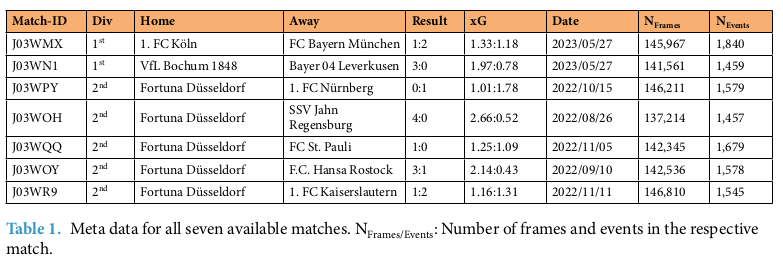

## Daten laden

Nachfolgend der Code, um die Daten zu laden. Zunächst importierst du das *dataset* Objekt, mit dem kannst du dann anschließend einzelne Spiele laden.

In [6]:
DATA_DIR = '/home/max/drive/data/openData2223/'
ls_match_ids = ['J03WMX', 'J03WN1', 'J03WPY', 'J03WOH', 'J03WQQ', 'J03WOY', 'J03WR9']

In [7]:
match_id = 'J03WPY'

In [8]:
path_positions = os.path.join(DATA_DIR, [x for x in os.listdir(DATA_DIR) if match_id in x and 'positions' in x][0])
path_events = os.path.join(DATA_DIR, [x for x in os.listdir(DATA_DIR) if match_id in x and 'events' in x][0])
path_info = os.path.join(DATA_DIR, [x for x in os.listdir(DATA_DIR) if match_id in x and 'matchinformation' in x][0])

In [9]:
xy, possession, ballstatus, teamsheets, pitch = dfl.read_position_data_xml(path_positions, path_info, teamsheet_home=None, teamsheet_away=None)


In [10]:
events, teamsheets, pitch = dfl.read_event_data_xml(path_events, path_info)

Hier wird nun die ID für das jeweilige Spiel vergeben und die Positionsdaten geladen. Ich habe schon mal die ID für das Bochum - Leverkusen Spiel eingetragen, du kannst aber auch jedes andere Spiel aus der Liste oben verwenden.

Die *floodlight*-Konvention sieht vor, dass jedes Spiel aus den Events (die sind für uns hier erstmal irrelevant), einem *xy*-Objekt, einem np-array mit dem Ballbesitz, einem np-array mit dem Ballstatus (aktiv/nicht aktiv) sowie einem *teamsheets*-Objekt und einem *pitch*-Objekt besteht. Wichtig ist hier vor allem das *xy*-Objekt, das die Positionsdaten enthält und wiederum eigentlich ein dictionary ist, das die Daten erstmal nach Halbzeiten trennt und dann für beide Mannschaften sowie den Ball getrennt ausgibt. Mit dem Format muss man ein bisschen warm werden, aber alle Downstream-Analysen in *floodlight* sind an dieses Format angepasst, deshalb empfiehlt es sich, es einfach erstmal so zu verwenden.


In [11]:
pitch.sport = "football"

xy_firsthalf_home = xy['firstHalf']['Home']
xy_firsthalf_away = xy['firstHalf']['Away']

xy_secondhalf_home = xy['secondHalf']['Home']
xy_secondhalf_away = xy['secondHalf']['Away']

possession_firsthalf = possession['firstHalf']
possession_secondhalf = possession['secondHalf']

## Get Velocity

Hier wird aus den Positionsdaten die Geschwindigkeit berechnet, die wir ja für das regelbasierte Schneiden der Positionsdaten benötigen. Auch hier hat *floodlight* die entsprechenden Funktionen bereits implementiert und wir können einfach ein sogenanntes **VelocityModel**-Objekt aufrufen, das die Geschwindigkeit für uns berechnet. Ich speichere hier die Arrays mit den Geschwindigkeiten der Spieler für beide Teams und beide Halbzeiten in einem Velocity-Dictionary.

### Get Velocities for All Halves and Teams

In [12]:
vm = VelocityModel()

velocity_dict = {
    'firstHalf' : {'Home': None, 'Away': None},
    'secondHalf' : {'Home': None, 'Away': None}
                 }

vm.fit(xy_firsthalf_home)
velocity_dict['firstHalf']['Home'] = vm.velocity().property

vm.fit(xy_firsthalf_away)
velocity_dict['firstHalf']['Away'] = vm.velocity().property

vm.fit(xy_secondhalf_home)
velocity_dict['secondHalf']['Away'] = vm.velocity().property = vm.velocity().property

vm.fit(xy_secondhalf_away)
velocity_dict['secondHalf']['Home'] = vm.velocity().property

In [13]:
xy_filt = butterworth_lowpass(xy_firsthalf_home, remove_short_seqs=True, Wn=.5, order=1)

vm = VelocityModel()
am = AccelerationModel()
vm.fit(xy_filt)
velocity_1st_home = vm.velocity().property
am.fit(xy_filt)
acceleration_1st_home = am.acceleration().property

In [14]:
def moving_average(a, n=3):
    ret = np.nancumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

vel_rolling = moving_average(velocity_1st_home[:,9], n=20)

In [ ]:
MINS = 5
FRAMES = MINS * 60 * 25

plt.figure(figsize=(20,10))
#plt.plot(velocity_dict['firstHalf']['Home'][:FRAMES,9])
plt.plot(velocity_1st_home[:FRAMES,9])
#plt.plot(vel_rolling[:FRAMES])
#plt.plot(acceleration_1st_home[:FRAMES,9])

## Discrete Movement Segmentation (Llana et al. 2022)

Instead of extracting only frames above a velocity threshold, this approach **segments the entire speed signal** into discrete movements using **valley detection**. Local minima (valleys) in the smoothed speed signal serve as boundaries between consecutive movements. Each valley-to-valley segment is one discrete movement; its peak speed determines the speed category (walking / jogging / running / sprinting).

Three key reference points per movement (Llana et al. 2022, Ch. 2):
1. **Valley start (origin)** — where the player begins accelerating
2. **Peak frame** — frame of maximum speed; used to assign attack/defense context
3. **Peak end (destination)** — where the player starts decelerating

See `llana2022_movement_segmentation.md` for a full summary of the approach.

In [ ]:
# Timecode helpers (defined here so they are available for movement extraction;
# also redefined in the HI run section below — identical functions)
def sec_to_minute(seconds):
    minutes = seconds // 60
    seconds = seconds % 60
    return f"{int(minutes)}:{int(seconds):02d}"

def frame_to_minute(frame, frate=25):
    return sec_to_minute(frame / frate)


In [ ]:
def classify_speed_category(peak_speed_kmh, thresholds):
    if peak_speed_kmh < thresholds['walking']:
        return 'walking'
    elif peak_speed_kmh < thresholds['jogging']:
        return 'jogging'
    elif peak_speed_kmh < thresholds['running']:
        return 'running'
    else:
        return 'sprinting'


In [ ]:
# Speed category thresholds (km/h) — standard football science conventions
SPEED_THRESHOLDS = {'walking': 7, 'jogging': 14, 'running': 21}


# Compute Butterworth-filtered velocity for all halves and teams.
# Smoothed signal is better suited for valley detection than the raw derivative.
xy_all = {
    'firstHalf':  {'Home': xy_firsthalf_home,  'Away': xy_firsthalf_away},
    'secondHalf': {'Home': xy_secondhalf_home, 'Away': xy_secondhalf_away},
}

velocity_filtered_dict = {
    'firstHalf':  {'Home': None, 'Away': None},
    'secondHalf': {'Home': None, 'Away': None},
}

for half, teams in xy_all.items():
    for team, xy_data in teams.items():
        xy_f = butterworth_lowpass(xy_data, remove_short_seqs=True, Wn=0.5, order=1)
        vm_f = VelocityModel()
        vm_f.fit(xy_f)
        velocity_filtered_dict[half][team] = vm_f.velocity().property


In [ ]:

def extract_movements_for_player(player_id, velocities, tracking_data, possession,
                                  min_valley_distance=10):
    """
    Segment a player's speed signal into discrete movements via valley detection.

    Valleys (local minima) in the smoothed speed signal define segment boundaries.
    Each valley-to-valley interval represents one discrete movement. The start of
    each segment is the valley frame itself (origin = point of acceleration onset).

    Parameters
    ----------
    min_valley_distance : int
        Minimum number of frames between two valleys (avoids noise-driven splits).
        At 25 fps, 10 frames = 0.4 seconds.
    """
    player_velocity = velocities[:, player_id]  # m/s

    # Replace NaN with 0 for valley detection (NaN = player not tracked)
    vel_for_peaks = np.where(np.isnan(player_velocity), 0.0, player_velocity)

    # Find valleys = peaks of the negated signal
    valleys, _ = find_peaks(-vel_for_peaks, distance=min_valley_distance)

    # Use signal start and end as additional boundaries
    boundaries = np.unique(np.concatenate([[0], valleys, [len(player_velocity) - 1]]))

    movements = {}
    mov_idx = 0
    for i in range(len(boundaries) - 1):
        start = int(boundaries[i])
        end = int(boundaries[i + 1])  # exclusive: next valley is start of next segment

        if end - start < 3:
            continue

        frames = np.arange(start, end)
        v = player_velocity[start:end]

        if np.all(np.isnan(v)):
            continue

        x = tracking_data[start:end, ::2][:, player_id]
        y = tracking_data[start:end, 1::2][:, player_id]
        p = possession[start:end]

        movements[mov_idx] = pd.DataFrame({
            'frame': frames, 'x': x, 'y': y,
            'velocity': v, 'possession': p
        })
        mov_idx += 1

    return movements


def extract_discrete_movements_all_players(velocities, tracking_data, possession,
                                            min_valley_distance=10):
    """Extract discrete movements for all players in a tracking data array."""
    n_players = velocities.shape[1]
    return {
        player_id: extract_movements_for_player(
            player_id, velocities, tracking_data, possession, min_valley_distance)
        for player_id in range(n_players)
    }


def summarize_movements_to_dataframe(movements_dict, teamsheet, framerate=25):
    """
    Convert discrete movement data to a summary DataFrame (one row per movement).

    Columns mirror the HI run summary with additions:
    - peak_frame     : frame of maximum speed within the segment
    - x_peak, y_peak : position at peak speed (destination per Llana et al.)
    - peak_speed_kmh : maximum speed reached in this movement
    - speed_category : walking / jogging / running / sprinting
    """
    rows = []
    for xID, movements in movements_dict.items():
        player_info = teamsheet.loc[teamsheet['xID'] == xID]
        if player_info.empty:
            continue

        player_name = player_info['player'].values[0]
        position    = player_info['position'].values[0]
        team_name   = player_info['team'].values[0]
        jersey_id   = player_info['jID'].values[0]

        for mov_id, df in movements.items():
            if df.empty or df['velocity'].isna().all():
                continue

            v_ms = df['velocity'].values
            valid_v = np.where(np.isnan(v_ms), -np.inf, v_ms)
            peak_idx = int(np.argmax(valid_v))
            peak_speed_kmh = float(v_ms[peak_idx]) * 3.6 if not np.isnan(v_ms[peak_idx]) else 0.0

            deltas = df[['x', 'y']].diff().dropna()
            distance_m = np.sqrt((deltas ** 2).sum(axis=1)).sum()

            rows.append({
                'start_frame':      df['frame'].iloc[0],
                'end_frame':        df['frame'].iloc[-1],
                'peak_frame':       df['frame'].iloc[peak_idx],
                'xID':              xID,
                'player':           player_name,
                'position':         position,
                'team':             team_name,
                'possession':       "Home" if df['possession'].iloc[0] == 1 else "Away",
                'jID':              jersey_id,
                'x_start':          df['x'].iloc[0],
                'y_start':          df['y'].iloc[0],
                'x_end'  :          df['x'].iloc[-1],
                'y_end':            df['y'].iloc[-1],
                'x_peak':           df['x'].iloc[peak_idx],
                'y_peak':           df['y'].iloc[peak_idx],
                'peak_speed_kmh':   peak_speed_kmh,
                'speed_category':   classify_speed_category(peak_speed_kmh, SPEED_THRESHOLDS),
                'avg_velocity_kmh': np.nanmean(v_ms) * 3.6,
                'distance_m':       distance_m,
                'duration_s':       len(df) / framerate,
            })

    return pd.DataFrame(rows)


In [ ]:

# Extract discrete movements for all halves and teams
ls_movement_dfs = []

for half in ['firstHalf', 'secondHalf']:
    for team in ['Home', 'Away']:
        # read_event_data_xml does not call add_xIDs(), so the xID column is missing
        # from the teamsheets it returns. Add it here before passing to summarize().
        teamsheets[team].add_xIDs()

        xy_f = butterworth_lowpass(xy[half][team], remove_short_seqs=True, Wn=0.5, order=1).xy

        movements_dict = extract_discrete_movements_all_players(
            velocity_filtered_dict[half][team],
            xy_f,
            possession[half],
            min_valley_distance=10
        )
        summary_df = summarize_movements_to_dataframe(
            movements_dict, teamsheets[team].teamsheet, framerate=25)

        summary_df['half'] = half
        summary_df['location'] = team
        summary_df['start_timecode'] = summary_df.apply(
            lambda x: frame_to_minute(x['start_frame']) if x.half == 'firstHalf'
            else frame_to_minute(x['start_frame'] + 67500), axis=1)
        summary_df['end_timecode'] = summary_df.apply(
            lambda x: frame_to_minute(x['end_frame']) if x.half == 'firstHalf'
            else frame_to_minute(x['end_frame'] + 67500), axis=1)

        ls_movement_dfs.append(summary_df)

df_movements = pd.concat(ls_movement_dfs, ignore_index=True)
df_movements = df_movements[df_movements.distance_m > 0]
print(f"Total discrete movements extracted: {len(df_movements)}")
df_movements['speed_category'].value_counts()


Total discrete movements extracted: 46966


speed_category
walking      33504
jogging       8844
running       3679
sprinting      939
Name: count, dtype: int64

## Get Running Distances for All Players

In [56]:
ls_dfs_distance = []
for half, teams in xy_all.items():
    for team, xy_data in teams.items():
        xy_f = butterworth_lowpass(xy_data, remove_short_seqs=True, Wn=0.5, order=1)
        dm = DistanceModel()
        dm.fit(xy_f)
        df_players = teamsheets[team].teamsheet
        df_players['distance_covered'] = np.nansum(dm.distance_covered().property, axis=0)
        df_players['location'] = team
        df_players['half'] = half
        ls_dfs_distance.append(df_players)

In [57]:
df_distances = pd.concat(ls_dfs_distance).groupby(['location', 'team', 'player']).agg(
    total_distance_m=pd.NamedAgg(column='distance_covered', aggfunc='sum'),
    position=pd.NamedAgg(column='position', aggfunc='first'),
    jID=pd.NamedAgg(column='jID', aggfunc='first'),
)

## Compare Running Distances from Discrete Movements

In [58]:
pd.concat([
    pd.DataFrame(df_movements.groupby(['location', 'team', 'player']).distance_m.sum().sort_values(ascending=False)).round(2),
    df_distances
], axis=1).round()

distance_m  \
location team               player                              
Away     1. FC Nürnberg     C. Daferner               11277.0   
Home     Fortuna Düsseldorf M. Karbownik              10667.0   
Away     1. FC Nürnberg     L. Tempelmann             10584.0   
                            J. Castrop                10530.0   
Home     Fortuna Düsseldorf Tim Oberdorf              10486.0   
                            M. Sobottka               10478.0   
                            Matthias Zimmermann       10203.0   
Away     1. FC Nürnberg     James Lawrence            10106.0   
Home     Fortuna Düsseldorf Dawid Kownacki             9861.0   
Away     1. FC Nürnberg     Christopher Schindler      9440.0   
                            J. Geis                    9307.0   
                            Jan Gyamerah               9116.0   
Home     Fortuna Düsseldorf C. Klarer                  9101.0   
                            F. Klaus                   8944.0   
Away     1. FC Nürnberg     M. Møller Dæhli            8635.0   
                            F. Nürnberger              8162.0   
Home     Fortuna Düsseldorf Shinta Appelkamp           7715.0   
                            E. Iyoha                   7640.0   
                            A. Tanaka                  7388.0   
Away     1. FC Nürnberg     Kwadwo Duah                6723.0   
Home     Fortuna Düsseldorf F. Kastenmeier             5983.0   
Away     1. FC Nürnberg     C. Mathenia                5630.0   
Home     Fortuna Düsseldorf N. Gavory                  3876.0   
                            E. Fernandes Neto          3679.0   
Away     1. FC Nürnberg     L. Schleimer               3618.0   
                            E. Wekesser                3578.0   
Home     Fortuna Düsseldorf R. Hennings                3320.0   
Away     1. FC Nürnberg     Manuel Wintzheimer         2872.0   
Home     Fortuna Düsseldorf Kristoffer Peterson        2488.0   
Away     1. FC Nürnberg     S. Fofana                  1780.0   
                            E. Valentini               1520.0   
                            Bryang Kayo                   NaN   
                            C. Klaus                      NaN   
                            E. Shuranov                   NaN   
                            P. Köpke                      NaN   
Home     Fortuna Düsseldorf D. Bunk                       NaN   
                            Kwadwo Baah                   NaN   
                            N. Vukančić                   NaN   
                            R. Wolf                       NaN   
                            T. Geerkens                   NaN   

                                                   total_distance_m position  \
location team               player                                             
Away     1. FC Nürnberg     C. Daferner                     10931.0      STL   
Home     Fortuna Düsseldorf M. Karbownik                    10983.0       LV   
Away     1. FC Nürnberg     L. Tempelmann                   10041.0       ZO   
                            J. Castrop                      10578.0      ORM   
Home     Fortuna Düsseldorf Tim Oberdorf                    10199.0      IVR   
                            M. Sobottka                     10097.0      DML   
                            Matthias Zimmermann             10407.0       RV   
Away     1. FC Nürnberg     James Lawrence                   9963.0      IVL   
Home     Fortuna Düsseldorf Dawid Kownacki                   9714.0      STZ   
Away     1. FC Nürnberg     Christopher Schindler            9314.0      IVR   
                            J. Geis                          7735.0      DMZ   
                            Jan Gyamerah                     7555.0       RV   
Home     Fortuna Düsseldorf C. Klarer                        8671.0      IVL   
                            F. Klaus                         6591.0      ORM   
Away     1. FC Nürnberg     M. Møller Dæ

In [59]:
pd.DataFrame(df_movements[['player', 'speed_category']].value_counts()).unstack()

count                          
speed_category        jogging running sprinting walking
player                                                 
A. Tanaka                 295     151        25     878
C. Daferner               346     220        64    1421
C. Klarer                 392     122        29    1731
C. Mathenia               201      28         7    2352
Christopher Schindler     555     129        20    1453
Dawid Kownacki            292     138        55    1663
E. Fernandes Neto         126      62        22     529
E. Iyoha                  303     135        41     772
E. Valentini               82      26         4     158
E. Wekesser               112      46        19     527
F. Kastenmeier            206      39         2    2299
F. Klaus                  355     149        40     898
F. Nürnberger             325     125        28    1113
J. Castrop                441     189        57    1536
J. Geis                   368     170        28    1183
James Lawrence            534     151        35    1468
Jan Gyamerah              340     184        31    1236
Kristoffer Peterson        86      40        15     297
Kwadwo Duah               245      81        36     981
L. Schleimer              118      64        20     475
L. Tempelmann             372     186        45    1591
M. Karbownik              370     181        51    1524
M. Møller Dæhli           284     202        41     758
M. Sobottka               500     162        30    1494
Manuel Wintzheimer         80      72        15     228
Matthias Zimmermann       378     148        62    1512
N. Gavory                 139      75        23     459
R. Hennings               146      49        15     536
S. Fofana                  65      42        10     149
Shinta Appelkamp          322     151        37     804
Tim Oberdorf              466     162        32    1479

## Calculate Features of Runs

In [60]:
dx = df_movements['x_end'] - df_movements['x_start']
dy = df_movements['y_end'] - df_movements['y_start']

# direction: x-component of the L1-normalized displacement vector.
# Maps to [-1, 1] with intuitive landmarks:
#   1    = purely horizontal right
#  -1    = purely horizontal left
#   0    = purely vertical (up or down)
#   0.5  = 45° forward-diagonal
#  -0.5  = 45° backward-diagonal
df_movements['direction'] = (dx / (dx.abs() + dy.abs())).fillna(0)
df_movements['direction'].describe()

count    46966.000000
mean        -0.048273
std          0.589741
min         -0.999992
25%         -0.576986
50%         -0.112949
75%          0.494583
max          0.999933
Name: direction, dtype: float64

## Filter Movements Based on Deep Run Criteria

In [61]:
df_movements[
    (df_movements.possession == df_movements.location) &
    (df_movements.speed_category.isin(['jogging', 'running', 'sprinting'])) &
    (df_movements.duration_s > 2) &
    (df_movements.x_start > -30) &
    (df_movements.direction > 0.5)  # strong forward component
    #(df_movements.x_end > df_movements.x_start)  # ensure movement is towards opponent goal
    ]

,start_frame,end_frame,peak_frame,xID,player,position,team,possession,jID,x_start,...,peak_speed_kmh,speed_category,avg_velocity_kmh,distance_m,duration_s,half,location,start_timecode,end_timecode,direction
21,1319,1382,1357,2,Matthias Zimmermann,RV,Fortuna Düsseldorf,Home,25,15.878321,...,9.480088,jogging,5.467266,3.881713,2.56,firstHalf,Home,0:52,0:55,0.592584
55,3510,3594,3563,2,Matthias Zimmermann,RV,Fortuna Düsseldorf,Home,25,-8.759974,...,8.431757,jogging,7.161532,6.699008,3.40,firstHalf,Home,2:20,2:23,0.595576
56,3595,3680,3645,2,Matthias Zimmermann,RV,Fortuna Düsseldorf,Home,25,-3.268352,...,9.808652,jogging,8.199712,7.789147,3.44,firstHalf,Home,2:23,2:27,0.916066
120,8892,9039,8990,2,Matthias Zimmermann,RV,Fortuna Düsseldorf,Home,25,-23.078659,...,24.139862,sprinting,17.606847,28.797349,5.92,firstHalf,Home,5:55,6:01,0.740435
164,11942,12108,12062,2,Matthias Zimmermann,RV,Fortuna Düsseldorf,Home,25,8.350976,...,11.284854,jogging,5.362649,9.947627,6.68,firstHalf,Home,7:57,8:04,0.980242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46618,70273,70382,70280,16,J. Castrop,ORM,1. FC Nürnberg,Away,17,23.745123,...,8.832541,jogging,6.886299,8.338454,4.40,secondHalf,Away,91:50,91:55,0.670260
46654,72821,73061,72910,16,J. Castrop,ORM,1. FC Nürnberg,Away,17,-7.283103,...,22.697550,sprinting,14.796258,39.515549,9.64,secondHalf,Away,93:32,93:42,0.766180
46692,76175,76399,76338,16,J. Castrop,ORM,1. FC Nürnberg,Away,17,19.351132,...,13.688235,jogging,8.258832,20.631102,9.00,secondHalf,Away,95:47,95:55,0.807660
46856,70004,70172,70062,19,S. Fofana,DMZ,1. FC Nürnberg,Away,3,17.870532,...,18.212782,running,11.343585,21.244936,6.76,secondHalf,Away,91:40,91:46,0.649566


In [62]:
df_movements.groupby('speed_category').distance_m.describe().round(2)

,count,mean,std,min,25%,50%,75%,max
speed_category,,,,,,,,
jogging,8844.0,8.75,4.98,0.74,5.12,7.76,11.28,40.79
running,3679.0,17.64,8.29,1.41,11.72,16.31,22.06,55.28
sprinting,939.0,30.21,12.97,2.60,21.61,28.59,37.75,87.77
walking,33504.0,1.61,1.61,0.00,0.28,1.23,2.41,13.08


In [63]:
df_movements.distance_m.describe().round(2)


count    46966.00
mean         4.78
std          7.16
min          0.00
25%          0.63
50%          2.07
75%          5.49
max         87.77
Name: distance_m, dtype: float64

In [64]:
df_movements.distance_m.round().value_counts().sort_index()

distance_m
0.0     10633
1.0      8520
2.0      6775
3.0      4412
4.0      2898
        ...  
80.0        1
81.0        1
82.0        1
85.0        1
88.0        1
Name: count, Length: 76, dtype: int64

<Axes: >

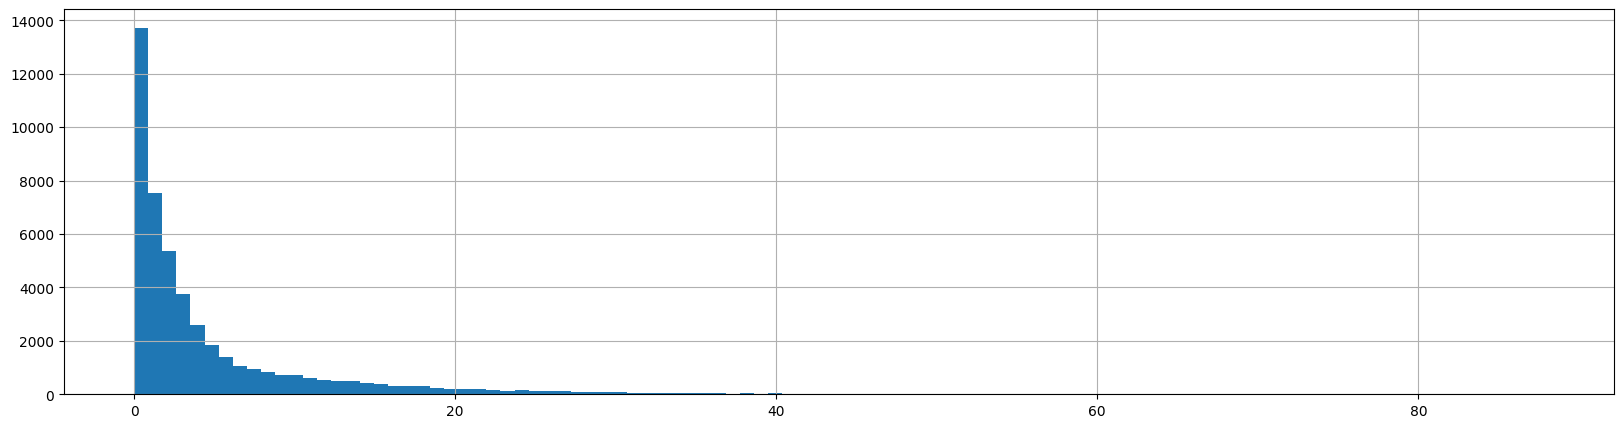

In [65]:
plt.figure(figsize=(20,5))
df_movements.distance_m.hist(bins=100)

In [66]:
df_movements.to_csv('data/movements/'+str(match_id)+'.csv', index=False)